# Batch simulating a Talsim dataset with scenarios

Given that you have a Talsim dataset with precipitation (or discharge) scenarios defined in a `*.PRO` file and you want to simulate all of them.

In [2]:
import logging
from pathlib import Path
import sys

import pandas as pd

from talsimpy import Timeseries
import talsimpy as talsim

In [3]:
# setup logging to see log messages in the notebook
# create a console handler
ch = logging.StreamHandler()
ch.setLevel(logging.INFO)
# add formatters to the handler
ch.setFormatter(logging.Formatter('%(name)-12s %(levelname)-8s %(message)s'))
# config
logging.basicConfig(
    level=logging.NOTSET,
    handlers=[ch],
    force=True
)

In [4]:
# instantiate a talsim dataset
tds = talsim.TalsimDataset(r"data/test_prognose", "test")
tds

TalsimDataset 'test' in data\test_prognose

In [ ]:
# instantiate a talsim engine
path_engine = r"<path_to_talsim_engine>"
engine = talsim.TalsimEngine(rf"{path_engine}")
engine

TalsimEngine in C:\data\Projekte\4.1.27

In [6]:
# define list of scenario IDs to process
prog_ids = list(range(1, 3))

In [7]:
# make sure SimMode is set to 2 in the ALL file
tds.set_sim_options({"SimMode": 2})

# simulation loop
for prog_id in prog_ids:

    print(f"Simulating ProgId {prog_id}...")
    
    # set the KProgID in the ALL file
    tds.set_sim_options({"KProgID": prog_id}) 
    
    # simulate
    success = engine.simulate(tds)
    if not success:
        print("Simulation error!")
        break
    
    # copy sim results to subfolder
    dir_results = tds.path / f"results_{prog_id:0>3}" 
    tds.copy_result_files(dir_results)


talsimpy.talsimengine INFO     Launching Talsim-NG v4.1.27...


Simulating ProgId 1...


talsimpy.talsimengine WARNING  Simulation produced warnings! See Talsim warning file: data\test_prognose\test.wrn
talsimpy.talsimengine INFO     Simulation successful!
talsimpy.talsimdataset INFO     Copying file test.MAX...
talsimpy.talsimdataset INFO     Copying file test.WMX...
talsimpy.talsimdataset INFO     Copying file test.BLZ...
talsimpy.talsimdataset INFO     Copying file test.wrn...
talsimpy.talsimdataset INFO     Copying file test.log...
talsimpy.talsimdataset INFO     Copying file test.WELINFO...
talsimpy.talsimdataset INFO     Copying file test.WEL...
talsimpy.talsimengine INFO     Launching Talsim-NG v4.1.27...


Simulating ProgId 2...


talsimpy.talsimengine WARNING  Simulation produced warnings! See Talsim warning file: data\test_prognose\test.wrn
talsimpy.talsimengine INFO     Simulation successful!
talsimpy.talsimdataset INFO     Copying file test.MAX...
talsimpy.talsimdataset INFO     Copying file test.WMX...
talsimpy.talsimdataset INFO     Copying file test.BLZ...
talsimpy.talsimdataset INFO     Copying file test.wrn...
talsimpy.talsimdataset INFO     Copying file test.log...
talsimpy.talsimdataset INFO     Copying file test.WELINFO...
talsimpy.talsimdataset INFO     Copying file test.WEL...


In [8]:
# read results
result_var = "S020_1AB"

ts_list = []

for prog_id in prog_ids:
    
    # find result file
    dir_results = tds.path / f"results_{prog_id:0>3}" 
    file_wel = dir_results / f"{tds.name}.WEL"

    # read results
    ts, = Timeseries.read_wel(file_wel, [result_var])

    # append prog_id to title
    ts.title += f" ({prog_id:0>3})"

    # store in list
    ts_list.append(ts)

# convert all to dataframe
df_results = Timeseries.to_dataframe(ts_list)
df_results

,S020_1AB (001),S020_1AB (002)
2014-01-01 00:00:00,0.445,0.445
2014-01-01 01:00:00,0.482,0.482
2014-01-01 02:00:00,0.483,0.483
2014-01-01 03:00:00,0.486,0.486
2014-01-01 04:00:00,0.489,0.489
...,...,...
2014-01-05 20:00:00,0.878,1.807
2014-01-05 21:00:00,0.865,1.781
2014-01-05 22:00:00,0.853,1.756
2014-01-05 23:00:00,0.842,1.733


<Axes: >

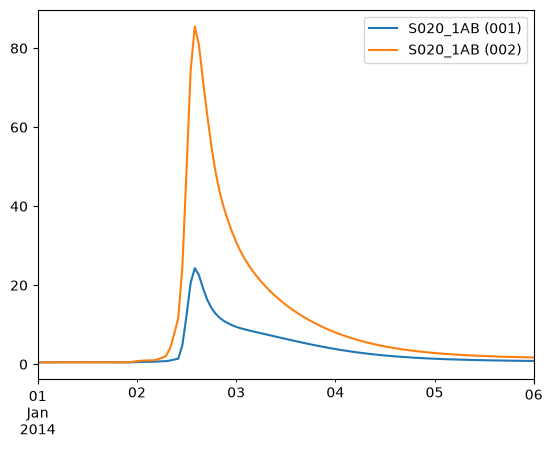

In [9]:
# plot results
df_results.plot()

In [ ]:
# export to Excel (CSV also possible)
df_results.to_excel(tds.path / f"{tds.name}_results.xlsx")